# Code Assignment Mod6L14 — Confusion Matrix & Metrics on Restaurant Inspections

**Format:** Instructor Guidance → Your Task → We Share (Reflection)

**Goal:** Using the same **classification workflow** and models as last time, build confusion matrices and calculate accuracy, precision, and recall of each model.  


## Instructor Guidance (Pseudocode + Docs)

Use this as a roadmap; students implement below.

**Docs (quick links):**
- Train/Test Split — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html  
- Logistic Regression — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html  
- Confusion Matrix / Classification Report — scikit-learn: https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics  
- `pandas.get_dummies` (one-hot) — https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html

### Guidance (same models as last challenge -- FEEL free to copy and paste the code that you need from the last code assignment)

1) **Load CSV** → preview shape & columns.  
2) **Define target (y)** as a **binary** label: e.g., `CRITICAL FLAG == "Critical"` → 1, else 0 *(positive class = “Critical”)*.  
3) **Pick features (X)**: start small (`SCORE`), then add categorical dummies (`BORO`, `CUISINE DESCRIPTION`), keep it simple.  
4) **Minimal prep**: coerce **only used columns** to numeric (for numeric features); `get_dummies` for categoricals (`drop_first=True`). Drop NA rows on used cols.  
5) **Train–test split (80/20)** with fixed `random_state`.  
6) **Fit the same model** as last time (e.g., `LogisticRegression`), predict on **test**.  
7) **Evaluate**: confusion matrix, **accuracy**, **precision**, **recall**, **F1** (classification_report).  
8) **Repeat for 2 more models** (A (baseline)/B (single term)/C (more than one term)) on the **same split**; compare metrics.  
9) **Decide** which model is better for the business goal based on **precision vs recall** trade-offs.  


## Your Task

Work in pairs. Comment your choices briefly. Keep code simple and readable.

> **Reminder (last challenge model):** You trained **LogisticRegression**, on three models you will use those same 3 models!


### 1) Read the Restaurant Inspection CSV & Preview

In [56]:
import pandas as pd, numpy as np
import statsmodels.api as sm
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import dataprep
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix



pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

array([[<Axes: title={'center': 'SCORE'}>]], dtype=object)

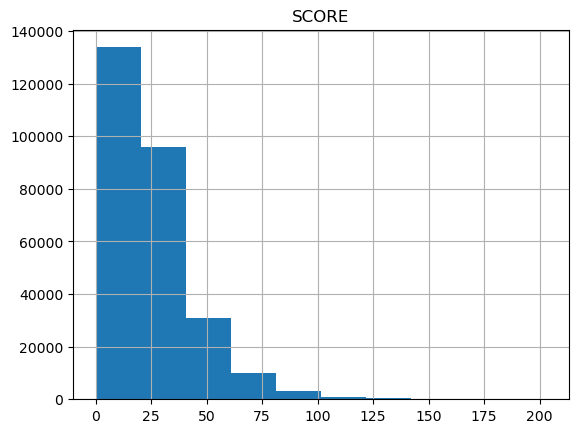

In [63]:
df = pd.read_csv('/Users/Marcy_Student/Downloads/DOHMH_New_York_City_Restaurant_Inspection_Results_20251104 copy.csv')


df.head()

data = df[['ACTION','VIOLATION CODE','SCORE','INSPECTION TYPE','CRITICAL FLAG','BORO','CUISINE DESCRIPTION','GRADE']]
df.dtypes
data.dtypes
data.hist()

### 2) Define the Binary Target (y)

We’ll predict whether an inspection had a **Critical violation**.

- Target rule: `CRITICAL FLAG == "Critical"` → **1**, else **0**.
- Positive class = **1 (Critical)** — keep this in mind for **precision/recall** meaning.


In [64]:
# Dropping rows with missing SCORE 
data = data.dropna(subset=['SCORE'])

# Filling missing GRADE by mapping SCORE (A:0-13, B:14-27, C:28+) - score found in google
data['SCORE'] = pd.to_numeric(data['SCORE'], errors='coerce')
missing_rows = data['GRADE'].isna()
def score_to_grade(s):
    if pd.isna(s):
        return np.nan
    if s <= 13:
        return 'A'
    if s <= 27:
        return 'B'
    return 'C'

filled = data.loc[missing_rows, 'SCORE'].apply(score_to_grade)
data.loc[missing_rows, 'GRADE'] = filled

data.info()

# feature engineering
data['is_A'] = (data['GRADE'] == 'A').astype(int)
data['critical'] = (data['CRITICAL FLAG'] == 'Critical').astype(int)
data.head()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 274939 entries, 18 to 291277
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ACTION               274939 non-null  object 
 1   VIOLATION CODE       273397 non-null  object 
 2   SCORE                274939 non-null  float64
 3   INSPECTION TYPE      274939 non-null  object 
 4   CRITICAL FLAG        274939 non-null  object 
 5   BORO                 274939 non-null  object 
 6   CUISINE DESCRIPTION  274939 non-null  object 
 7   GRADE                274939 non-null  object 
dtypes: float64(1), object(7)
memory usage: 18.9+ MB


,ACTION,VIOLATION CODE,SCORE,INSPECTION TYPE,CRITICAL FLAG,BORO,CUISINE DESCRIPTION,GRADE,is_A,critical
18,Violations were cited in the following area(s).,04L,13.0000,Cycle Inspection / Initial Inspection,Critical,Brooklyn,Italian,A,1,1
19,No violations were recorded at the time of thi...,NaN,0.0000,Inter-Agency Task Force / Initial Inspection,Not Applicable,Brooklyn,African,A,1,0
36,Violations were cited in the following area(s).,08A,13.0000,Pre-permit (Operational) / Initial Inspection,Not Critical,Manhattan,Other,A,1,0
37,Establishment re-opened by DOHMH.,NaN,0.0000,Cycle Inspection / Reopening Inspection,Not Applicable,Manhattan,Pizza,P,0,0
54,No violations were recorded at the time of thi...,NaN,0.0000,Cycle Inspection / Initial Inspection,Not Applicable,Brooklyn,Chinese,A,1,0


### 3) Create Three Models (you can copy and paste the same modeling code from last code assignment here it is okay if your models have different features as long as you have 3 models)

- **Model A (minimal numeric):** `SCORE` only (lower is better in NYC scoring).  
- **Model B (add location):** `SCORE` + one-hot `BORO`.  
- **Model C (richer categories):** `SCORE` + one-hot `BORO` + top cuisines (one-hot of `CUISINE DESCRIPTION` limited to most frequent K).

> If any column is missing in your file, skip that spec or adjust accordingly.


### 4) Minimal Cleaning: Drop NAs in Used Columns

Do this **per model** so each spec uses its own “clean” subset (same **target** slice).


In [75]:
data = data[['SCORE','CUISINE DESCRIPTION','BORO','critical']]
data = data.dropna()
data.isna().value_counts()
data.isnull().sum()

SCORE                  0
CUISINE DESCRIPTION    0
BORO                   0
critical               0
dtype: int64

In [76]:
x1 = data['SCORE']
x2 = data['CUISINE DESCRIPTION']
x3 = data ['BORO']
y = data['critical']

Xs = data[['SCORE','CUISINE DESCRIPTION','BORO']]

### 5) Train–Test Split (same split for all models)

Use **the same random_state** so models A/B/C are comparable.


In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    Xs, y,
    test_size=0.3,
    random_state= 42,
    shuffle = True,
    stratify = y
)

In [78]:
# encodeer function, Luc I tried this function, I don't understand everything of it, but I think it does a good job
# I understand the concept behind it, which is to use the target mean to encode the categorical value, which is give
# continuous variable, work well with logisitic regression, the k_fold will subset the train data to avoid leakage, since the target
# variable is being used to compute the encoding, it's like cheating on the model, it could cause overfitting
# to avoid that, k_fold will allow us the compute the corresponding target mean using oothers subsets, that way, the trainmodel do not see the corresponding target which we are trying to predict
def target_encode(train_col, train_target, test_col, n_splits=5, alpha=10):

    train_col = train_col.reset_index(drop=True) #training categorical column 
    train_target = train_target.reset_index(drop=True) # training target column
    test_col = test_col.reset_index(drop=True) # test categorical column 
    
    prior = train_target.mean()  # global mean of target
    oof_encoded = pd.Series(index=train_col.index, dtype=float)
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)  # placeholder for encoded training values
    
    for train_idx, val_idx in kf.split(train_col):
        tr_cat = train_col.iloc[train_idx]
        tr_tgt = train_target.iloc[train_idx]
        
        # compute mean and count per category in the fold's training part
        stats = tr_tgt.groupby(tr_cat).agg(['mean','count'])

        # smoothing
        stats['enc'] = (stats['mean'] * stats['count'] + prior * alpha) / (stats['count'] + alpha)
        val_cat = train_col.iloc[val_idx]
        oof_encoded.iloc[val_idx] = val_cat.map(stats['enc']).fillna(prior)
    
    full_stats = train_target.groupby(train_col).agg(['mean','count'])
    full_stats['enc'] = (full_stats['mean'] * full_stats['count'] + prior * alpha) / (full_stats['count'] + alpha)
    test_encoded = test_col.map(full_stats['enc']).fillna(prior)
    
    return oof_encoded, test_encoded
# Apply encoding
X_train['cuisine_te'], X_test['cuisine_te'] = target_encode(
    X_train['CUISINE DESCRIPTION'],
    y_train,
    X_test['CUISINE DESCRIPTION'],
    n_splits=5,
    alpha=10
)


### 6) Fit the Same Models on the Train sets (Logistic Regression), Get Predictions, Print Confusion Matrices & Metric Reports

> **This is new**:  Be sure to look up documentation on `confusion_matrix` and `classification_report`.  Get a matrix and metrics report (accuracy, precision, recall, f1) for each model.


In [79]:
# Model A: SCORE only (minimal numeric baseline)
X_train1 = X_train[['SCORE']] 
X_test1 = X_test[['SCORE']]

model1 = LogisticRegression()
model1.fit(X_train1,y_train)
y1_prediction = model1.predict(X_test1)

accuracy = accuracy_score(y_test, y1_prediction)
precision = precision_score(y_test, y1_prediction, zero_division=0)
recall = recall_score(y_test, y1_prediction, zero_division=0)
f1 = f1_score(y_test, y1_prediction, zero_division=0)
cm = confusion_matrix(y_test, y1_prediction, labels=[0, 1])

print("Test set evaluation:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1       : {f1:.4f}")
print("Confusion matrix [rows=true, cols=pred] (0,1):")
print(cm)

Test set evaluation:
  Accuracy : 0.5936
  Precision: 0.5939
  Recall   : 0.8676
  F1       : 0.7052
Confusion matrix [rows=true, cols=pred] (0,1):
[[ 8883 27403]
 [ 6115 40081]]


In [ ]:
# Model B: SCORE BORO AND CUISINE DESCRIPTION
####
from sklearn.impute import SimpleImputer # for handling NAN
preprocessing = ColumnTransformer(
    transformers=[
        ('numerical', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), ['SCORE','cuisine_te']),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), ['BORO'])
        ],
    remainder='passthrough' 
)

my_pipeline = Pipeline(steps=[
    ('Process', preprocessing),
    ('logistic_model',LogisticRegression())
])

display(my_pipeline)

X_train2 = X_train[['SCORE','cuisine_te','BORO']]
X_test2 = X_test[['SCORE','cuisine_te','BORO']]

my_pipeline.fit(X_train2, y_train)

y2_prediction = my_pipeline.predict(X_test2)

accuracy2 = accuracy_score(y_test, y2_prediction)
precision2 = precision_score(y_test, y2_prediction, zero_division=0)
recall2 = recall_score(y_test, y2_prediction, zero_division=0)
f1_2 = f1_score(y_test, y2_prediction, zero_division=0)
cm2 = confusion_matrix(y_test, y2_prediction, labels=[0, 1])

print("Model B - Test set evaluation:")
print(f"  Accuracy : {accuracy2:.4f}")
print(f"  Precision: {precision2:.4f}")
print(f"  Recall   : {recall2:.4f}")
print(f"  F1       : {f1_2:.4f}")
print("Confusion matrix [rows=true, cols=pred] (0,1):")
print(cm2)


Pipeline(steps=[('Process',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SCORE', 'cuisine_te']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BORO'])])),
                ('logistic_model', LogisticRegression())])

Model B - Test set evaluation:
  Accuracy : 0.5938
  Precision: 0.5942
  Recall   : 0.8665
  F1       : 0.7050
Confusion matrix [rows=true, cols=pred] (0,1):
[[ 8944 27342]
 [ 6166 40030]]


### 7) Visualize One Confusion Matrix 

Be able to interpret this Matrix 

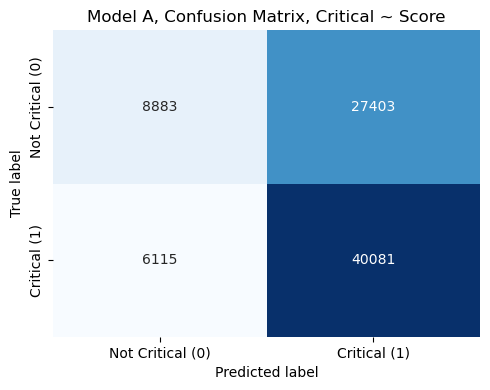

In [102]:
# model_A confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Not Critical (0)', 'Critical (1)'],
    yticklabels=['Not Critical (0)', 'Critical (1)']
)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Model A, Confusion Matrix, Critical ~ Score')
plt.tight_layout()
plt.show()

### 8) Decide Which Model Is “Better” — Explain Your Metric Choice

- If the **cost of missing a Critical** violation is high → prioritize **Recall** on the positive class.  
- If the **cost of wrongly flagging Critical** is high → prioritize **Precision** on the positive class.  
- If you want a balance → **F1**.

Write 3–5 sentences justifying your pick using the table above (Precision/Recall/F1).

First, both models perform similarly, they both have the same evaluation stats, accurately and precision are 59%, recall 86% and f1_score 70%.
Since model A only uses 1 feature, it is the best for simplicity.
If they had different stats, I would certainly chose the best model based on the highest f1, for balancing reason. I think both cases missing a critical or wrongly flagging one can have tremendous consequences, for public health on one side, and business survival on the other side. 
wrongly flagging a restaurant would result to lost of business and missing a violation can also threat consumers safety.
using f1 as comparison to find that balance seem to be a best compromis.


## We Share (Reflection)

1) **Chosen model (A/B/C)** and **why**, referencing **Precision/Recall/F1** for the **Critical (1)** class.  
2) Your **confusion matrix** and a one-liner in plain English:  
   - “Out of all inspections we predicted **Critical**, **X%** were actually Critical (Precision).  
   - Of all actually **Critical** inspections, we caught **Y%** (Recall).”  

In the first model:
- Out of all inspections we predicted critical, 59% were actually critical
- Of all actually critical inspections, we caught 86%.
